# Ti-6Al-4V Cutting Thermal Model

Flash temperature, surface and subsurface temperature, and thermally induced residual stress for orthogonal cutting of Ti-6Al-4V. The model follows the reference workbook (`ref/ME599 Spreadsheet with RS and Ti64, 304SS and AA6061.xlsx`); all physics lives in `model.py`, and this notebook shows the same results as the Streamlit UI (`app.py`).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from model import (RHO, TI64, SHEET_DATA, SHEET_DATA_H, SHEET_FEEDS, T_CRIT_SPEED, Constants,
                   critical_speed_fit, cutting_force, feed_sweep, initial_guess,
                   residual_stress, solve, thermoelastic_stress)

## Inputs

In [2]:
v_m_min = 120.0  # cutting speed (m/min); sheet range 6-300
h_mm    = 0.05   # feed / uncut chip thickness (mm); sheet range up to 0.12
w_mm    = 3.0    # width of cut (mm)

# Sheet constants
consts = Constants(
    shear_angle_deg=35.0,
    rake_angle_deg=0.0,
    clearance_angle_deg=5.0,
    edge_radius_um=10.0,
    a_low=0.95,    # calibration factor, Pe < 5
    a_high=0.90,   # calibration factor, Pe > 5
)
T_init = initial_guess()      # initial temperature guess (deg C): halfway between ambient and melting
T_crit_speed = T_CRIT_SPEED   # Tc used for the critical speed (deg C)

## Cutting force

$F_c = 1793\,h^{-0.117}\,w\,h\,\dfrac{100-\gamma}{100}\cdot 0.7$ with $h$, $w$ in mm and rake angle $\gamma$ in degrees.

In [3]:
s = solve(v_m_min, h_mm, w_mm, consts, T_init)
r = s.row
print(f"Fc = {r.Fc:.1f} N")

Fc = 267.3 N


## Contact half-width, heat partition and flash temperature

Shear plane: $l_s = h/\sin\phi$, $\;Pe_s = \dfrac{v\,l_s\,\rho c_p}{4k}$, $\;\delta = \sqrt{l_s^2/Pe_s}$, $\;l_{int} = \delta/\sin\phi$, $\;l_{ext} = \dfrac{r_\beta}{2\tan\alpha}$.

Contact half-width $b = (l_{int} + l_{ext})/2$ and heat partition $R = \min(1,\,0.6\,Pe_s^{-0.4})$, with $k$, $c_p$ at the initial temperature. Then $Pe = \dfrac{v\rho b c_p}{2k}$ and

- $Pe < 5$: $\;\Delta T = a_1\,0.159\,C_4\,\dfrac{2RF_c}{\rho c_p w b},\quad C_4 = 0.00527Pe^3 - 0.192Pe^2 + 2.39Pe$
- $Pe > 5$: $\;\Delta T = a_2\,0.399\,\dfrac{2RF_c v}{k w}\sqrt{\dfrac{k}{\rho c_p v b}}$

Both chains run five passes, re-evaluating $k$, $c_p$ at each pass's temperature. The flash temperature is the mean of passes 2-5 of the chain selected by the mean $Pe$ (high chain if $> 5$).

Peak surface T       = 561.5 C
Flash temperature    = 541.5 C
Peclet number (mean) = 12.371   (chain used: Pe > 5)
Contact half-width b = 56.8 um   (contact length 2b = 113.6 um)
Heat partition R     = 0.272
Pe (shear plane)     = 7.243
k, cp at initial T   = 22.55 W/(m K), 832.8 J/(kg K)
Density              = 4500 kg/m^3
Initial guess        = 840 C


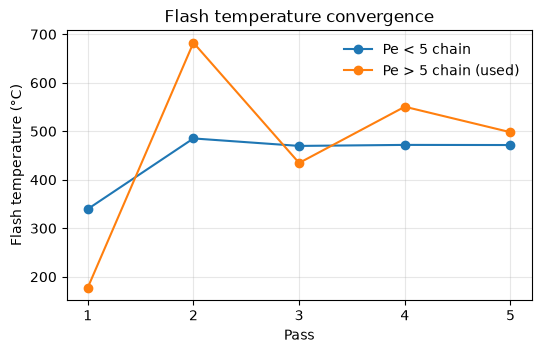

In [4]:
print(f"Peak surface T       = {s.peak_surface_C:.1f} C")
print(f"Flash temperature    = {r.T_flash:.1f} C")
print(f"Peclet number (mean) = {r.Pe:.3f}   (chain used: {'Pe > 5' if r.Pe > 5 else 'Pe < 5'})")
print(f"Contact half-width b = {r.b * 1e6:.1f} um   (contact length 2b = {2 * r.b * 1e6:.1f} um)")
print(f"Heat partition R     = {r.partition:.3f}")
print(f"Pe (shear plane)     = {r.Pe_shear:.3f}")
print(f"k, cp at initial T   = {r.k:.2f} W/(m K), {r.cp:.1f} J/(kg K)")
print(f"Density              = {RHO:g} kg/m^3")
print(f"Initial guess        = {r.T_initial:.0f} C")

fig, ax = plt.subplots(figsize=(6, 3.5))
used_high = r.Pe > 5
ax.plot(range(1, 6), r.low, "o-", label="Pe < 5 chain" + ("" if used_high else " (used)"))
ax.plot(range(1, 6), r.high, "o-", color="C1", label="Pe > 5 chain" + (" (used)" if used_high else ""))
ax.set(title="Flash temperature convergence", xlabel="Pass", ylabel="Flash temperature (°C)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(frameon=False)
ax.grid(alpha=0.3)

## Surface temperature (1D)

Moving band source (Liu 2004), with $P_\pm = Pe\,(x/b \pm 1)/2$; for $-1 < x/b < 1$:

$f(x) = (x/b+1)\,e^{P_+}\left[K_0(P_+) + K_1(P_+)\right] + (1-x/b)\,e^{P_-}\left[K_0(-P_-) - K_1(-P_-)\right]$

(the outer branches swap the sign convention). The shape is normalized to peak 1, then $T(x) = T_0 + \Delta T\, f(x)/f_{max}$ with $T_0 = 20$ °C.

Peak at x/b = 0.89


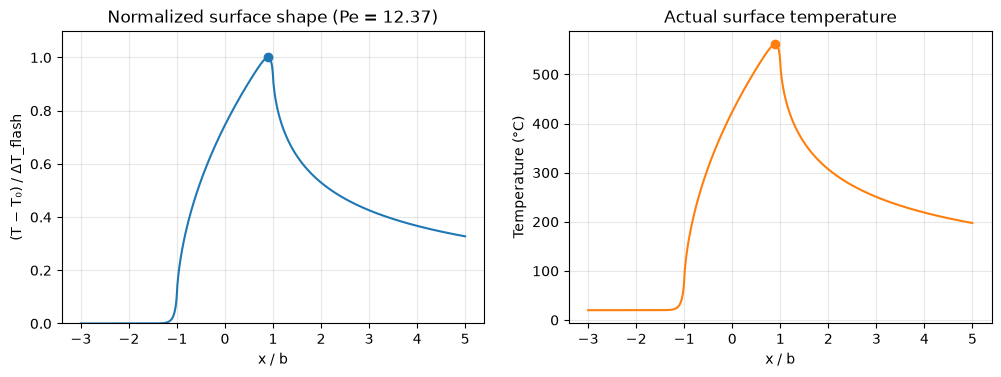

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(s.x_over_b, s.shape)
a1.plot(s.peak_x_over_b, 1.0, "o", color="C0")
a1.set(title=f"Normalized surface shape (Pe = {r.Pe:.2f})", xlabel="x / b", ylabel="(T − T₀) / ΔT_flash", ylim=(0, 1.1))
a2.plot(s.x_over_b, s.T_surface_C, color="C1")
a2.plot(s.peak_x_over_b, s.peak_surface_C, "o", color="C1")
a2.set(title="Actual surface temperature", xlabel="x / b", ylabel="Temperature (°C)")
for a in (a1, a2):
    a.grid(alpha=0.3)
print(f"Peak at x/b = {s.peak_x_over_b:.2f}")

## Subsurface temperature and residual stress (2D)

$T(x, z) = \max\!\left(T_0,\; T(x)\left[1 - \operatorname{erf}\!\left(\dfrac{z}{\sqrt{4\alpha t}}\right)\right]\right),\quad \alpha = \dfrac{k}{\rho c_p},\; t = \dfrac{2b}{v}$

Critical temperature $T_{crit}$: lowest $T$ (1 °C steps) where $\dfrac{E\,\alpha_{th}\,(T - T_0)}{1-\nu} > \sigma_y(T)$. Above it, $\sigma_{RS} = 2.8788\,T - 1365.2$ MPa (tensile +); below it, $\sigma_{RS} = 0$. The residual-stress profile is taken at the flank, $x/b = 0.999$.

Critical T (yield)  = 480.0 C
Surface RS at flank = 145.4 MPa
Yielded depth       = 2.6 um


[Text(0.5, 1.0, 'Subsurface temperature with residual stress'),
 Text(0.5, 0, 'x / b'),
 Text(0, 0.5, 'z / b (depth)'),
 (-2.918, 4.999),
 (1.1307416479381835, 0.0)]

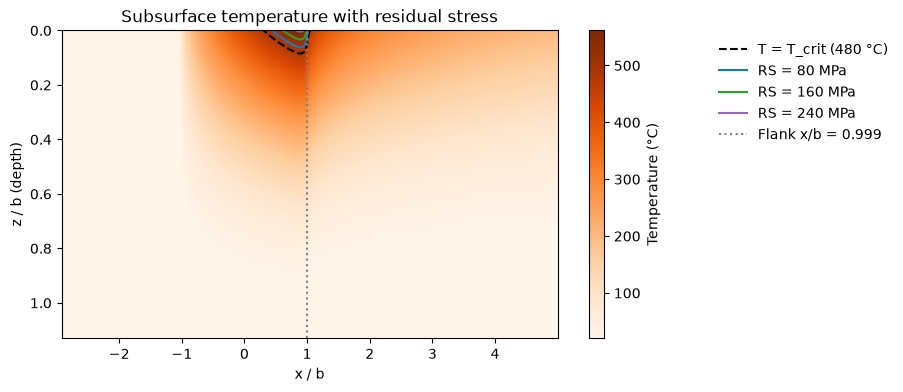

In [6]:
Tc = s.T_critical_C
rs_field = residual_stress(s.T_field_C, Tc)
yielded = s.z_over_b[s.residual_stress_MPa > 0]

print(f"Critical T (yield)  = {Tc:.1f} C")
print(f"Surface RS at flank = {s.residual_stress_MPa[0]:.1f} MPa")
print(f"Yielded depth       = {yielded.max() * r.b * 1e6 if yielded.size else 0:.1f} um")

# crop to where the field is noticeably above ambient
rise = s.T_field_C - s.T_field_C.min()
hot = rise > 0.02 * rise.max()
x_hot, z_hot = s.x_over_b[hot.any(axis=0)], s.z_over_b[hot.any(axis=1)]
pad = max(0.3 * (x_hot.max() - x_hot.min()), 0.5)
x_lo, x_hi = max(x_hot.min() - pad, s.x_over_b[0]), min(x_hot.max() + pad, s.x_over_b[-1])
z_hi = min(max(1.3 * z_hot.max(), 0.15), s.z_over_b[-1])

fig, ax = plt.subplots(figsize=(8, 4))
mesh = ax.pcolormesh(s.x_over_b, s.z_over_b, s.T_field_C, cmap="Oranges", shading="auto")
fig.colorbar(mesh, ax=ax, label="Temperature (°C)")
if rs_field.max() > 0:
    ax.contour(s.x_over_b, s.z_over_b, s.T_field_C, levels=[Tc], colors="k", linestyles="dashed")
    ax.plot([], [], "k--", label=f"T = T_crit ({Tc:.0f} °C)")
    for color, level in zip(["C0", "C2", "C4", "C9"], MaxNLocator(4).tick_values(0, rs_field.max())[1:-1]):
        ax.contour(s.x_over_b, s.z_over_b, rs_field, levels=[level], colors=[color])
        ax.plot([], [], color=color, label=f"RS = {level:.0f} MPa")
ax.axvline(s.flank_x_over_b, color="gray", ls=":")
ax.plot([], [], ":", color="gray", label=f"Flank x/b = {s.flank_x_over_b:g}")
ax.legend(loc="upper left", bbox_to_anchor=(1.3, 1.0), frameon=False)
ax.set(title="Subsurface temperature with residual stress", xlabel="x / b", ylabel="z / b (depth)",
       xlim=(x_lo, x_hi), ylim=(z_hi, 0))

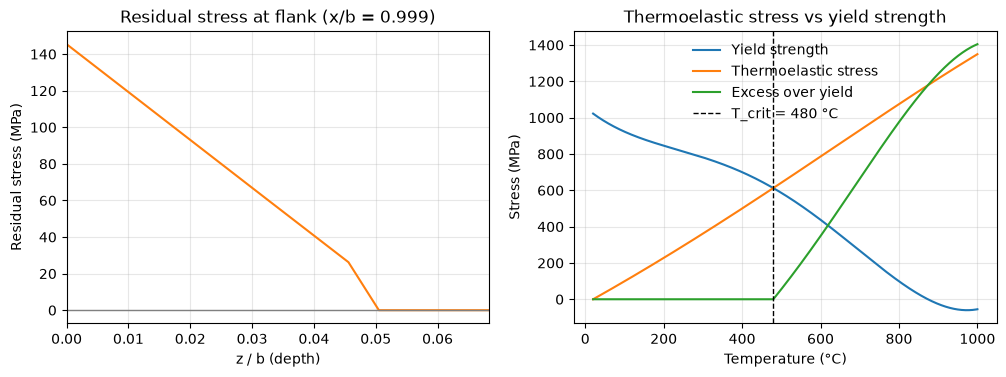

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(s.z_over_b, s.residual_stress_MPa, color="C1")
a1.axhline(0, color="gray", lw=1)
a1.set(title=f"Residual stress at flank (x/b = {s.flank_x_over_b:g})", xlabel="z / b (depth)", ylabel="Residual stress (MPa)",
       xlim=(0, 1.5 * yielded.max() if yielded.size else z_hi))

T = np.arange(20.0, 1001.0)
yield_strength, thermal = TI64["sigma_y"](T), thermoelastic_stress(T)
a2.plot(T, yield_strength, label="Yield strength")
a2.plot(T, thermal, label="Thermoelastic stress")
a2.plot(T, np.maximum(thermal - yield_strength, 0.0), label="Excess over yield")
a2.axvline(Tc, color="k", ls="--", lw=1, label=f"T_crit = {Tc:.0f} °C")
a2.set(title="Thermoelastic stress vs yield strength", xlabel="Temperature (°C)", ylabel="Stress (MPa)")
a2.legend(frameon=False)
for a in (a1, a2):
    a.grid(alpha=0.3)

## Machining sweeps

For each feed the speed is swept from 0.1 to 5 m/s in 0.1 m/s steps, each row starting from the previous row's flash temperature. Flash temperature is then fitted two ways (Excel LOGEST / LINEST):

$T = a\,v^{n}$ gives $v_{crit} = (T_c/a)^{1/n}$, and $T = m\ln v + c$ gives $v_{crit} = e^{(T_c - c)/m}$. The critical speed used is their average, fitted against feed as $v_{crit} = a\,h^{n}$.

Critical speed at h = 0.05 mm (Tc = 500 C):
  power-law fit 110.0 m/min,  log fit 100.1 m/min,  average 105.1 m/min

  h (mm)   power-law   log fit   average   (m/min)
   0.015       662.3    1388.2    1025.2
    0.03       230.1     249.3     239.7
    0.05       110.0     100.1     105.1
    0.08        59.2      52.0      55.6
    0.12        35.5      32.1      33.8

Fit to average: v_crit = 0.9168 * h^-1.632  (v in m/min, h in mm)


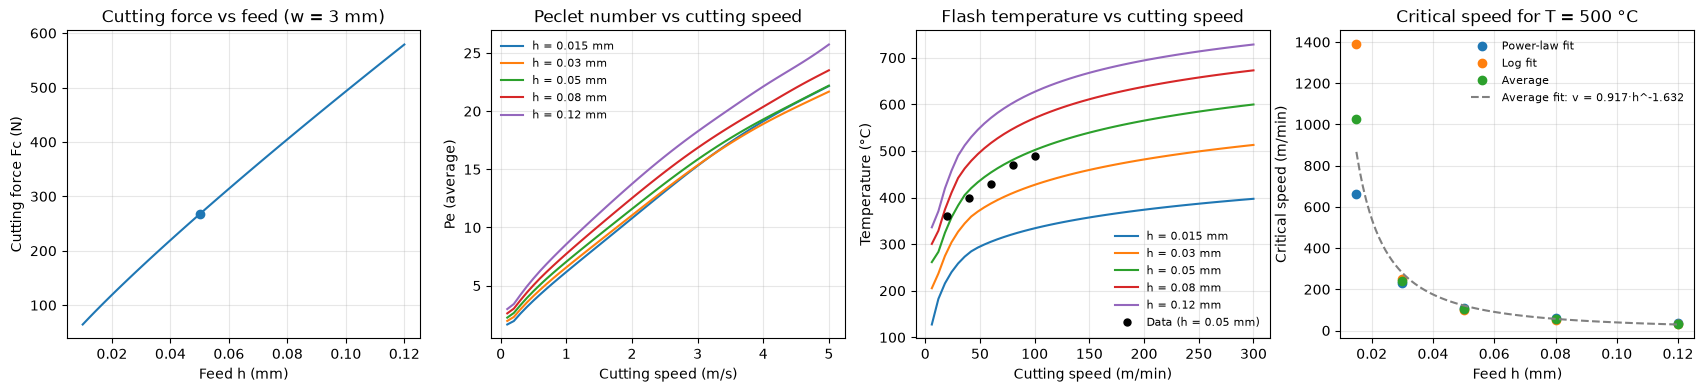

In [8]:
feeds = sorted({*SHEET_FEEDS, round(h_mm, 6)})
sweeps = [feed_sweep(x, w_mm, T_init, consts, T_crit_speed) for x in feeds]
here = sweeps[feeds.index(round(h_mm, 6))]
print(f"Critical speed at h = {h_mm} mm (Tc = {T_crit_speed:g} C):")
print(f"  power-law fit {here.v_crit_power:.1f} m/min,  log fit {here.v_crit_log:.1f} m/min,  average {here.v_crit_avg:.1f} m/min")
print("\n  h (mm)   power-law   log fit   average   (m/min)")
for fs in sweeps:
    print(f"  {fs.h_mm:6g}   {fs.v_crit_power:9.1f} {fs.v_crit_log:9.1f} {fs.v_crit_avg:9.1f}")

hh = np.array(feeds)
a, n = critical_speed_fit(hh, [fs.v_crit_avg for fs in sweeps])
print(f"\nFit to average: v_crit = {a:.4g} * h^{n:.3f}  (v in m/min, h in mm)")

fig, axs = plt.subplots(1, 4, figsize=(21, 4))
h_f = np.linspace(0.01, 0.12, 50)
axs[0].plot(h_f, cutting_force(h_f, w_mm))
axs[0].plot(h_mm, cutting_force(h_mm, w_mm), "o", color="C0")
axs[0].set(title=f"Cutting force vs feed (w = {w_mm:g} mm)", xlabel="Feed h (mm)", ylabel="Cutting force Fc (N)")
for fs in sweeps:
    axs[1].plot(fs.v_m_min / 60, fs.Pe, label=f"h = {fs.h_mm:g} mm")
    axs[2].plot(fs.v_m_min, fs.T_flash, label=f"h = {fs.h_mm:g} mm")
axs[1].set(title="Peclet number vs cutting speed", xlabel="Cutting speed (m/s)", ylabel="Pe (average)")
v_d, T_d = zip(*SHEET_DATA)
axs[2].plot(v_d, T_d, "ko", markersize=5, label=f"Data (h = {SHEET_DATA_H:g} mm)")
axs[2].set(title="Flash temperature vs cutting speed", xlabel="Cutting speed (m/min)", ylabel="Temperature (°C)")
axs[3].plot(hh, [fs.v_crit_power for fs in sweeps], "o", label="Power-law fit")
axs[3].plot(hh, [fs.v_crit_log for fs in sweeps], "o", label="Log fit")
axs[3].plot(hh, [fs.v_crit_avg for fs in sweeps], "o", label="Average")
h_c = np.linspace(hh.min(), hh.max(), 100)
axs[3].plot(h_c, a * h_c**n, "--", color="gray", label=f"Average fit: v = {a:.3g}·h^{n:.3f}")
axs[3].set(title=f"Critical speed for T = {T_crit_speed:g} °C", xlabel="Feed h (mm)", ylabel="Critical speed (m/min)")
for ax in axs:
    ax.grid(alpha=0.3)
    if ax is not axs[0]:
        ax.legend(frameon=False, fontsize=8)